# Task 1.2 — Offering Strategy Under a Two-Price Balancing Scheme


---

## Objective

Repeat Task 1.1 under the **two-price balancing scheme**: determine the optimal day-ahead (DA) offering strategy for a price-taking 500 MW wind farm, compute the expected profit, illustrate the profit distribution, and compare with the one-price results.

---

## What is the Two-Price Scheme?

Under the **two-price** balancing mechanism, the settlement price that the wind farm receives for its imbalance depends on **whether its deviation helps or hurts the power system**:

| System state | Wind farm deviation | Settlement price applied to imbalance |
|---|---|---|
| Deficit (SI = 1) | Over-production δ⁺ → **beneficial** | λ_B = 1.25 × λ_DA  *(rewarded at balancing price)* |
| Deficit (SI = 1) | Under-production δ⁻ → **harmful**   | λ_DA                *(penalised at DA price, NOT λ_B)* |
| Surplus (SI = 0) | Under-production δ⁻ → **beneficial** | λ_B = 0.85 × λ_DA  *(rewarded at balancing price)* |
| Surplus (SI = 0) | Over-production δ⁺  → **harmful**   | λ_DA                *(penalised at DA price, NOT λ_B)* |

**Key idea:** under two-price, a *beneficial* imbalance is rewarded at the balancing price (which is either high or low depending on system state), while a *harmful* imbalance is only penalised at the day-ahead price. This asymmetry **always favours** the wind farm compared to one-price, where *all* imbalances are settled at λ_B regardless of their direction.

---

## Profit Formulas

Let $\delta^+_{t,\omega} = \max(0,\, W_{t,\omega} - p_t^{DA})$ (over-production) and $\delta^-_{t,\omega} = \max(0,\, p_t^{DA} - W_{t,\omega})$ (under-production).

**If SI = 1 (deficit system):**
$$
\Pi_{t,\omega} = \lambda^{DA}_{t,\omega} \cdot p_t^{DA} + \lambda^{B}_{t,\omega} \cdot \delta^+_{t,\omega} - \lambda^{DA}_{t,\omega} \cdot \delta^-_{t,\omega}
$$

**If SI = 0 (surplus system):**
$$
\Pi_{t,\omega} = \lambda^{DA}_{t,\omega} \cdot p_t^{DA} + \lambda^{B}_{t,\omega} \cdot \delta^-_{t,\omega} - \lambda^{DA}_{t,\omega} \cdot \delta^+_{t,\omega}
$$

where $\lambda^{B}_{t,\omega} = 1.25 \cdot \lambda^{DA}_{t,\omega}$ if SI=1, and $\lambda^{B}_{t,\omega} = 0.85 \cdot \lambda^{DA}_{t,\omega}$ if SI=0.

---

## Stochastic Optimisation Problem

$$
\max_{p_t^{DA}} \; \frac{1}{|\Omega|} \sum_{\omega \in \Omega} \sum_{t=1}^{24} \Pi_{t,\omega}
$$

subject to:
$$
0 \leq p_t^{DA} \leq P_{\max} = 500 \text{ MW}, \quad \forall t
$$
$$
W_{t,\omega} - p_t^{DA} = \delta^+_{t,\omega} - \delta^-_{t,\omega}, \quad \forall t, \omega
$$
$$
\delta^+_{t,\omega},\; \delta^-_{t,\omega} \geq 0, \quad \forall t, \omega
$$

Note that $\delta^+$ and $\delta^-$ are **second-stage (recourse) variables**: they are decided after the scenario is revealed, so they can vary per scenario. The first-stage decision $p_t^{DA}$ must be fixed before uncertainty is resolved.

---

## Contrast with One-Price

Under the **one-price** scheme (Task 1.1), the profit is simply:
$$
\Pi_{t,\omega}^{\text{1P}} = \lambda^{DA}_{t,\omega} \cdot p_t^{DA} + \left(W_{t,\omega} - p_t^{DA}\right) \cdot \lambda^{B}_{t,\omega}
$$
There are no $\delta^+$ / $\delta^-$ variables — the *entire* imbalance always gets λ_B. This means:
- One-price model has only $T = 24$ variables → can handle all 1600 scenarios easily.
- Two-price model needs $T + 2 \times T \times N$ variables (δ⁺ and δ⁻ per scenario per hour).

In [15]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

## Step 1 — Load Scenario Data

We use the same three scenario files generated in the preprocessing step:
- **wind_realizations.csv**: 20 wind power scenarios × 24 hours (MW)
- **da_price_scenarios.csv**: 20 day-ahead price scenarios × 24 hours (€/MWh)
- **imbalance_scenarios_random.csv**: 4 system imbalance (SI) scenarios × 24 hours (0 = surplus, 1 = deficit)

Total combined scenarios = 20 × 20 × 4 = **1,600** (satisfies the ≥ 1,600 requirement).

In [16]:
# ============================================================
# STEP 1 — LOAD DATA
# ============================================================

wind = pd.read_csv("../data/processed/wind_realizations.csv") 
price = pd.read_csv("../data/processed/da_price_scenarios.csv")
imbalance = pd.read_csv("../data/processed/imbalance_scenarios_random.csv")

# Drop the 'Hour' index column; keep only the scenario columns
W         = wind.iloc[:, 1:].values       # shape: (24, 20)
lambda_DA = price.iloc[:, 1:].values      # shape: (24, 20)
SI        = imbalance.iloc[:, 1:].values  # shape: (24, 4)  — 0=surplus, 1=deficit

# Problem constants
T     = 24       # hours in a day
P_max = 500.0    # installed capacity [MW]

N_w = W.shape[1]         # 20 wind scenarios
N_p = lambda_DA.shape[1] # 20 price scenarios
N_s = SI.shape[1]        # 4 imbalance scenarios

print(f'Wind shape:      {W.shape}   ({N_w} scenarios)')
print(f'Price shape:     {lambda_DA.shape}   ({N_p} scenarios)')
print(f'Imbalance shape: {SI.shape}    ({N_s} scenarios)')

Wind shape:      (24, 20)   (20 scenarios)
Price shape:     (24, 20)   (20 scenarios)
Imbalance shape: (24, 4)    (4 scenarios)


## Step 2 — Build All 1,600 Combined Scenarios

We form the Cartesian product of the three independent uncertainty sources:
- Each combined scenario ω = (wind scenario i, price scenario j, imbalance scenario k)
- All 1,600 scenarios are equally probable: π_ω = 1/1600

The balancing price is derived from the DA price and system imbalance state:
- **Deficit** (SI=1): λ_B = 1.25 × λ_DA
- **Surplus** (SI=0): λ_B = 0.85 × λ_DA

In [17]:
# ============================================================
# STEP 2 — BUILD FULL CARTESIAN SCENARIO SET (1,600 scenarios)
# ============================================================

# Repeat wind: each wind scenario is repeated N_p*N_s times (for every price/SI combo)
W_full = np.repeat(W, N_p * N_s, axis=1)                         # (24, 1600)

# Tile price: repeat each price scenario N_s times, then tile over all wind scenarios
lambda_DA_full = np.tile(np.repeat(lambda_DA, N_s, axis=1), (1, N_w))  # (24, 1600)

# Tile imbalance: tile SI across all wind × price combinations
SI_full = np.tile(SI, (1, N_w * N_p))                            # (24, 1600)

# Compute balancing price for each combined scenario
# Deficit  (SI=1): λ_B = 1.25 × λ_DA  (balancing price > DA price)
# Surplus  (SI=0): λ_B = 0.85 × λ_DA  (balancing price < DA price)
lambda_B_full = np.where(
    SI_full == 1,
    1.25 * lambda_DA_full,
    0.85 * lambda_DA_full
)

N_full = W_full.shape[1]  # should be 1600
print(f'Total combined scenarios: {N_full}  (>= 1600: {N_full >= 1600})')
print(f'Combined matrix shape: {W_full.shape}')
print(f'\nDeficit fraction across scenarios: {SI_full.mean():.2%}')

Total combined scenarios: 1600  (>= 1600: True)
Combined matrix shape: (24, 1600)

Deficit fraction across scenarios: 47.92%


## Step 3 — Re-solve Task 1.1 (One-Price) for Comparison

We solve the one-price model on all 1,600 scenarios here to have a fair baseline for comparison. The one-price model is simple because there are **no δ⁺/δ⁻ recourse variables** — the whole imbalance $(W - p^{DA})$ is settled at λ_B. This means only 24 variables, so all 1,600 scenarios are tractable.

In [18]:
# ============================================================
# STEP 3 — TASK 1.1 ONE-PRICE MODEL (all 1600 scenarios)
# Used only to reproduce 1P results for the final comparison plot.
# ============================================================

m1 = gp.Model('one_price')
m1.setParam('OutputFlag', 0)  # suppress solver output for cleanliness

# First-stage decision: day-ahead offer per hour
p1 = m1.addVars(T, lb=0.0, ub=P_max, name='p_DA')

# Build objective: max expected profit under one-price settlement
# Profit_1P = λ_DA * p_DA + (W - p_DA) * λ_B
#           = W * λ_B + p_DA * (λ_DA - λ_B)
# Since W*λ_B is a constant w.r.t. p_DA, the optimal p_DA depends only on
# the sign of E[λ_DA - λ_B] → bang-bang (all-or-nothing) solution
obj1 = gp.LinExpr()
for t in range(T):
    for w in range(N_full):
        obj1 += (1.0 / N_full) * (
            p1[t] * lambda_DA_full[t, w]
            + (W_full[t, w] - p1[t]) * lambda_B_full[t, w]
        )

m1.setObjective(obj1, GRB.MAXIMIZE)
m1.optimize()

# Extract results
p_opt_1p = np.array([p1[t].X for t in range(T)])
obj_1p   = m1.ObjVal

# Compute per-scenario profits for the one-price offers
profits_1p = np.zeros(N_full)
for w in range(N_full):
    for t in range(T):
        profits_1p[w] += (
            p_opt_1p[t] * lambda_DA_full[t, w]
            + (W_full[t, w] - p_opt_1p[t]) * lambda_B_full[t, w]
        )

print('=== Task 1.1 — One-Price Results ===')
print(f'Expected profit : €{obj_1p:>12,.2f}')
print(f'Std of profit   : €{profits_1p.std():>12,.2f}')
print(f'Hours at   0 MW : {sum(p_opt_1p < 1)}')
print(f'Hours at 500 MW : {sum(p_opt_1p > 499)}')

=== Task 1.1 — One-Price Results ===
Expected profit : €  464,595.22
Std of profit   : €  340,871.49
Hours at   0 MW : 15
Hours at 500 MW : 9


## Step 4 — Two-Price Model: Licence Constraint & Scenario Reduction

The two-price model introduces **per-scenario recourse variables** $\delta^+_{t,\omega}$ and $\delta^-_{t,\omega}$.

**Variable count:**
$$
\text{Variables} = T + 2 \times T \times N = 24 + 48N
$$

The Gurobi **free/academic licence** limits us to **≤ 2,000 variables**:
$$
24 + 48N \leq 2000 \implies N \leq 41
$$

We therefore **randomly sample N = 40 scenarios** from the 1,600-scenario pool. The optimised offers will then be evaluated on all 1,600 scenarios to get a fair comparison with Task 1.1.

In [19]:
# ============================================================
# STEP 4 — SCENARIO REDUCTION FOR TWO-PRICE MODEL
#
# The two-price model requires per-scenario recourse variables
# δ⁺[t,w] and δ⁻[t,w], which grows the variable count to:
#   T + 2*T*N  variables
#   T*N        constraints (imbalance equalities)
#
# Gurobi free licence limit: 2000 variables → max N = 41 scenarios.
# We use N = 40 for a safe margin.
# ============================================================

N_sample = 40   # scenarios used in the two-price optimisation

# Verify we stay within the Gurobi free licence limit
n_vars   = T + 2 * T * N_sample   # p_DA[T] + delta_pos[T,N] + delta_neg[T,N]
n_constrs = T * N_sample           # one imbalance equality per (t, w)
assert n_vars <= 2000,   f'Variable limit exceeded: {n_vars} > 2000'
assert n_constrs <= 2000, f'Constraint limit exceeded: {n_constrs} > 2000'
print(f'Variables:   {n_vars:4d}  (limit: 2000 ✓)')
print(f'Constraints: {n_constrs:4d}  (limit: 2000 ✓)')

# Random sample (seed for reproducibility)
np.random.seed(42)
selected = np.random.choice(N_full, N_sample, replace=False)

# Subset scenario arrays to the N_sample selected columns
W_s         = W_full[:, selected]          # (24, 40)
lambda_DA_s = lambda_DA_full[:, selected]  # (24, 40)
lambda_B_s  = lambda_B_full[:, selected]   # (24, 40)
SI_s        = SI_full[:, selected]         # (24, 40)

N  = N_sample
pi = 1.0 / N   # equal probability weight per scenario

print(f'\nSampled {N} scenarios from {N_full} for two-price optimisation.')
print(f'Wind range:    [{W_s.min():.1f}, {W_s.max():.1f}] MW')
print(f'Price range:   [{lambda_DA_s.min():.2f}, {lambda_DA_s.max():.2f}] €/MWh')
print(f'Deficit frac:  {SI_s.mean():.2%}')

Variables:   1944  (limit: 2000 ✓)
Constraints:  960  (limit: 2000 ✓)

Sampled 40 scenarios from 1600 for two-price optimisation.
Wind range:    [3.3, 482.1] MW
Price range:   [1.00, 466.44] €/MWh
Deficit frac:  46.98%


## Step 5 — Build & Solve the Two-Price Optimisation Model

**Decision variables:**
- $p_t^{DA}$ — first-stage: DA offer at hour $t$ (same for all scenarios)
- $\delta^+_{t,\omega}$ — second-stage: over-production in scenario $\omega$ at hour $t$
- $\delta^-_{t,\omega}$ — second-stage: under-production in scenario $\omega$ at hour $t$

**Imbalance decomposition constraint:**  
$$W_{t,\omega} - p_t^{DA} = \delta^+_{t,\omega} - \delta^-_{t,\omega}$$

Combined with non-negativity, this ensures at most one of $\delta^+$, $\delta^-$ is non-zero per scenario per hour (since wind power is non-negative and $p^{DA} \leq P_{max}$, the LP relaxation correctly handles this without explicit binary variables).

In [20]:
# ============================================================
# STEP 5 — BUILD TWO-PRICE GUROBI MODEL
# ============================================================

m2 = gp.Model('two_price')
m2.setParam('OutputFlag', 1)  # show solver log

# ── First-stage variable (must be decided before uncertainty is revealed) ─────
# p_DA[t]: energy offered to the day-ahead market at hour t
p2 = m2.addVars(T, lb=0.0, ub=P_max, name='p_DA')

# ── Second-stage recourse variables (one per scenario per hour) ───────────────
# delta_pos[t,w]: over-production = max(0, W[t,w] - p_DA[t])
# delta_neg[t,w]: under-production = max(0, p_DA[t] - W[t,w])
# Both are non-negative and bounded by P_max
delta_pos = m2.addVars(T, N, lb=0.0, ub=P_max, name='dpos')
delta_neg = m2.addVars(T, N, lb=0.0, ub=P_max, name='dneg')

# ── Imbalance decomposition constraints ───────────────────────────────────────
# W[t,w] - p_DA[t] = δ⁺[t,w] - δ⁻[t,w]  for all t, w
# This links the first-stage decision p_DA to the second-stage imbalance.
# The LP structure ensures complementarity (no need for binary variables).
for t in range(T):
    for w in range(N):
        m2.addConstr(
            W_s[t, w] - p2[t] == delta_pos[t, w] - delta_neg[t, w],
            name=f'imbal_t{t}_w{w}'
        )

print(f'Model built.  Variables: {m2.NumVars}   Constraints: {m2.NumConstrs}')

Set parameter OutputFlag to value 1
Model built.  Variables: 0   Constraints: 0


## Step 6 — Two-Price Objective Function

The objective differs from one-price because the settlement **depends on the direction** of the imbalance relative to the system state (Lecture 5b, slide 81):

**SI = 1 (deficit):**
- Over-production δ⁺ is **beneficial** → rewarded at λ_B = 1.25 × λ_DA
- Under-production δ⁻ is **harmful** → penalised at **λ_DA** (not λ_B, which would be *more* expensive)

**SI = 0 (surplus):**
- Under-production δ⁻ is **beneficial** → settled at **λ_DA** (no penalty vs DA price)
- Over-production δ⁺ is **harmful** → penalised at **λ_DA** (not λ_B = 0.85·λ_DA, which would be a lighter penalty)

This asymmetry makes two-price strictly **more profitable** than one-price:
- In deficit, harmful δ⁻ costs only λ_DA instead of 1.25·λ_DA under one-price.
- In surplus, beneficial δ⁻ earns λ_DA instead of only 0.85·λ_DA under one-price.


In [21]:
# ============================================
# STEP 6 — TWO-PRICE OBJECTIVE FUNCTION (FIXED)
# ============================================

obj2 = gp.LinExpr()

for t in range(T):
    for w in range(N):

        lda = float(lambda_DA_s[t, w])   # day-ahead price
        lb  = float(lambda_B_s[t, w])    # balancing price (1.25*DA or 0.85*DA)
        si  = int(SI_s[t, w])            # 1 = deficit, 0 = surplus

        # Day-ahead revenue (same for all cases)
        da_rev = lda * p2[t]

        # Balancing settlement (TWO-PRICE — CORRECT)
        if si == 1:
            # DEFICIT system:
            # over-production helps → paid DA
            # under-production hurts → penalised at BP (> DA)
            bal_rev = lda * delta_pos[t, w] - lb * delta_neg[t, w]

        else:
            # SURPLUS system:
            # under-production helps → settled at DA
            # over-production hurts → penalised at BP (< DA)
            bal_rev = -lda * delta_neg[t, w] + lb * delta_pos[t, w]

        # Add scenario contribution
        obj2 += pi * (da_rev + bal_rev)

# Set objective
m2.setObjective(obj2, GRB.MAXIMIZE)

print("Two-price objective set.")

Two-price objective set.


In [22]:
# ============================================================
# STEP 7 — SOLVE
# ============================================================

m2.optimize()

STATUS = {1:'LOADED', 2:'OPTIMAL', 3:'INFEASIBLE', 4:'INF_OR_UNBD', 5:'UNBOUNDED'}
print(f'\nSolver status: {m2.status} ({STATUS.get(m2.status, "OTHER")})')

if m2.status == GRB.OPTIMAL:
    p_opt_2p = np.array([p2[t].X for t in range(T)])
    obj_2p   = m2.ObjVal
    print(f'\nExpected profit (two-price, in-sample): €{obj_2p:,.2f}')
    print('\nOptimal DA offers [MW]:')
    for t in range(T):
        mark = '← zero' if p_opt_2p[t] < 1 else ('← MAX' if p_opt_2p[t] > 499 else '')
        print(f'  Hour {t+1:2d}: {p_opt_2p[t]:6.1f} MW  {mark}')
else:
    raise RuntimeError(f'Solver did not find optimal solution. Status = {m2.status}')

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i9-14900KF, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 960 rows, 1944 columns and 2880 nonzeros
Model fingerprint: 0xbbbb66d2
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e-02, 1e+02]
  Bounds range     [5e+02, 5e+02]
  RHS range        [3e+00, 5e+02]
Presolve time: 0.00s
Presolved: 960 rows, 1944 columns, 2880 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.2874848e+06   1.009808e+05   0.000000e+00      0s
    1453    3.4371247e+05   0.000000e+00   0.000000e+00      0s

Solved in 1453 iterations and 0.01 seconds (0.01 work units)
Optimal objective  3.437124687e+05

Solver status: 2 (OPTIMAL)

Expected profit (two-price, in-sample): €343,712.47

Optimal DA offers [MW]:
  Hour  1:   32.4 MW  
  Hour  2:  219.4 MW 

## Step 8 — Evaluate Two-Price Offers on All 1,600 Scenarios

The optimisation used only N = 40 scenarios (due to licence limits). To get a **fair comparison** with Task 1.1 (which used all 1,600), we now evaluate the obtained DA offers $p^{DA*}$ on all 1,600 scenarios. This is an **out-of-optimisation** evaluation — no new optimisation is run, just profit calculation.

In [23]:
# ============================================================
# STEP 8 — EVALUATE TWO-PRICE OFFERS ON ALL 1,600 SCENARIOS
#
# Applies the same corrected two-price settlement rules as Step 6.
# ============================================================

profits_2p = np.zeros(N_full)

for w in range(N_full):
    pw = 0.0
    for t in range(T):
        lda = float(lambda_DA_full[t, w])
        lb  = float(lambda_B_full[t, w])
        si  = int(SI_full[t, w])
        p   = p_opt_2p[t]

        dp = max(0.0, W_full[t, w] - p)   # δ⁺ = over-production
        dn = max(0.0, p - W_full[t, w])   # δ⁻ = under-production

        if si == 1:
            # DEFICIT: δ⁺ beneficial → λ_B; δ⁻ harmful → λ_DA
            pw += lda * p + lb * dp - lda * dn
        else:
            # SURPLUS: δ⁻ beneficial → λ_DA; δ⁺ harmful → λ_DA
            pw += lda * p + lda * dn - lda * dp

    profits_2p[w] = pw

print("=== Task 1.2 — Two-Price (evaluated on all 1,600 scenarios) ===")
print(f'Expected profit : €{profits_2p.mean():>12,.2f}')
print(f'Std of profit   : €{profits_2p.std():>12,.2f}')
print(f'P10 (10th pctl) : €{np.percentile(profits_2p, 10):>12,.2f}')
print(f'P90 (90th pctl) : €{np.percentile(profits_2p, 90):>12,.2f}')
print(f'Min             : €{profits_2p.min():>12,.2f}')
print(f'Max             : €{profits_2p.max():>12,.2f}')
print(f'Hours at   0 MW : {sum(p_opt_2p < 1)}')
print(f'Hours at 500 MW : {sum(p_opt_2p > 499)}')


=== Task 1.2 — Two-Price (evaluated on all 1,600 scenarios) ===
Expected profit : €  363,628.76
Std of profit   : €  152,030.56
P10 (10th pctl) : €  179,637.86
P90 (90th pctl) : €  563,802.32
Min             : €   13,544.79
Max             : €1,072,553.13
Hours at   0 MW : 1
Hours at 500 MW : 1


## Step 9 — All-or-Nothing Bidding Check

Like in Task 1.1, we check whether the two-price solution exhibits **bang-bang (all-or-nothing) bidding**.

Under two-price, the marginal value of p_DA for each scenario is:

- **Deficit (SI=1):** ∂Π/∂p_DA = λ_DA − λ_DA = 0 (when δ⁻ active) or λ_DA − λ_B < 0 (when δ⁺ active, since λ_B > λ_DA). So reducing p_DA is always beneficial in deficit → bid 0 MW.
- **Surplus (SI=0):** ∂Π/∂p_DA = λ_DA − λ_DA = 0 always (both δ⁺ and δ⁻ settled at λ_DA). The DA revenue λ_DA·p_DA is the only term that varies → bid 500 MW to maximise DA revenue.

The profit is still **piecewise-linear in p_DA**, so the optimum lies at a corner (0 or P_max) for each hour, producing all-or-nothing bidding. The balance between deficit and surplus scenarios determines which corner is chosen per hour.


In [24]:
# ============================================================
# STEP 9 — ALL-OR-NOTHING BIDDING CHECK
# ============================================================

tol = 1.0  # 1 MW tolerance for numerical precision

hours_zero    = [t+1 for t in range(T) if p_opt_2p[t] < tol]
hours_cap     = [t+1 for t in range(T) if p_opt_2p[t] > P_max - tol]
hours_between = [t+1 for t in range(T) if tol <= p_opt_2p[t] <= P_max - tol]

print('=== All-or-Nothing Bidding Check (Two-Price) ===')
print(f'Hours offering   0 MW : {hours_zero}  ({len(hours_zero)} hours)')
print(f'Hours offering 500 MW : {hours_cap}  ({len(hours_cap)} hours)')
print(f'Intermediate offers   : {hours_between}  ({len(hours_between)} hours)')
frac_extreme = (len(hours_zero) + len(hours_cap)) / T
print(f'\nExtreme bids (0 or max): {frac_extreme:.0%} of hours')

if not hours_between:
    print('\n→ Perfect ALL-OR-NOTHING bidding observed under two-price scheme.')
    print('  Explanation: The expected profit is still linear in p_DA because')
    print('  the two-price profit is piecewise-linear (not strictly concave).')
    print('  The optimum therefore always lies at a corner: p_DA = 0 or P_max.')
else:
    print('\n→ Some intermediate offers observed (may be due to small sample size).')

=== All-or-Nothing Bidding Check (Two-Price) ===
Hours offering   0 MW : [14]  (1 hours)
Hours offering 500 MW : [15]  (1 hours)
Intermediate offers   : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20, 21, 22, 23, 24]  (22 hours)

Extreme bids (0 or max): 8% of hours

→ Some intermediate offers observed (may be due to small sample size).


## Step 10 — Visualisation: Two-Price Results

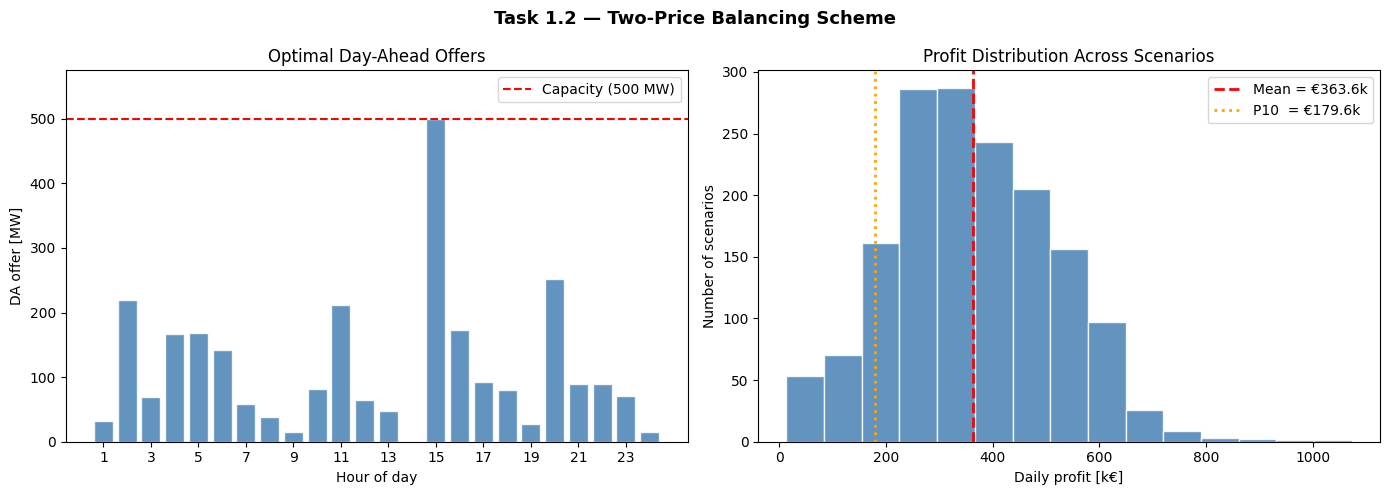

Figure saved as task1_2_results.pdf


In [25]:
# ============================================================
# STEP 10 — VISUALISATION: TWO-PRICE RESULTS (standalone)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 1.2 — Two-Price Balancing Scheme', fontsize=13, fontweight='bold')

hours = range(1, T + 1)

# ── Left: Optimal DA offers ──────────────────────────────────────────────────
ax = axes[0]
ax.bar(hours, p_opt_2p, color='steelblue', alpha=0.85, edgecolor='white')
ax.axhline(P_max, color='red', linestyle='--', linewidth=1.5,
           label=f'Capacity ({P_max:.0f} MW)')
ax.set_xlabel('Hour of day')
ax.set_ylabel('DA offer [MW]')
ax.set_title('Optimal Day-Ahead Offers')
ax.set_xticks(range(1, T + 1, 2))
ax.set_ylim(0, P_max * 1.15)
ax.legend()

# ── Right: Profit distribution ───────────────────────────────────────────────
ax = axes[1]
ax.hist(profits_2p / 1e3, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(profits_2p.mean() / 1e3, color='red', linestyle='--', linewidth=2,
           label=f'Mean = €{profits_2p.mean()/1e3:.1f}k')
ax.axvline(np.percentile(profits_2p, 10) / 1e3, color='orange', linestyle=':', linewidth=2,
           label=f'P10  = €{np.percentile(profits_2p, 10)/1e3:.1f}k')
ax.set_xlabel('Daily profit [k€]')
ax.set_ylabel('Number of scenarios')
ax.set_title('Profit Distribution Across Scenarios')
ax.legend()

plt.tight_layout()
plt.savefig('task1_2_results.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as task1_2_results.pdf')

## Step 11 — Full Comparison: One-Price vs Two-Price

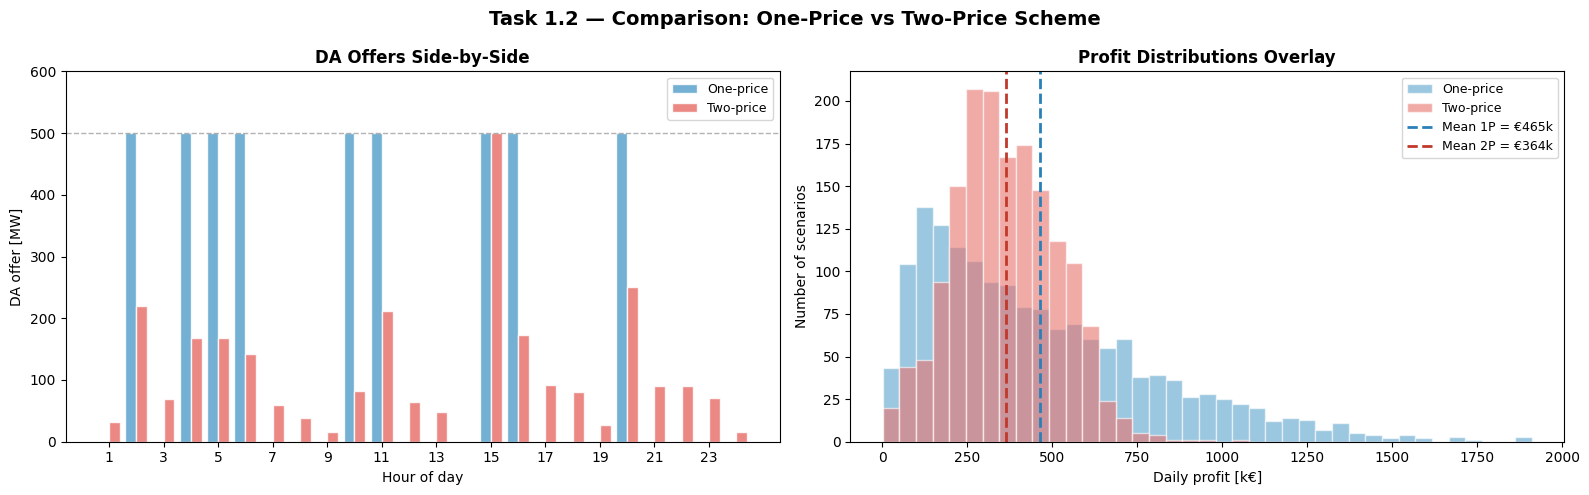

Comparison figure saved as task1_2_comparison.pdf


In [26]:
# STEP 11 — COMPARISON PLOT: One-Price vs Two-Price
hours = np.arange(1, T + 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Task 1.2 — Comparison: One-Price vs Two-Price Scheme',
             fontsize=14, fontweight='bold')

# ── Left: Side-by-side bar chart ─────────────────────────────
ax = axes[0]
width = 0.4
ax.bar(hours - width/2, p_opt_1p, width=width, color='#5ba3cc', alpha=0.85,
       edgecolor='white', label='One-price')
ax.bar(hours + width/2, p_opt_2p, width=width, color='#e8736d', alpha=0.85,
       edgecolor='white', label='Two-price')
ax.axhline(P_max, color='black', linestyle='--', linewidth=1, alpha=0.3)
ax.set_title('DA Offers Side-by-Side', fontweight='bold')
ax.set_xlabel('Hour of day')
ax.set_ylabel('DA offer [MW]')
ax.set_ylim(0, P_max * 1.2)
ax.set_xticks(range(1, T+1, 2))
ax.legend(fontsize=9)

# ── Right: Profit distribution overlay ───────────────────────
ax = axes[1]
bins = np.linspace(
    min(profits_1p.min(), profits_2p.min()) / 1e3,
    max(profits_1p.max(), profits_2p.max()) / 1e3,
    40
)
ax.hist(profits_1p / 1e3, bins=bins, color='#5ba3cc', alpha=0.6,
        edgecolor='white', label='One-price')
ax.hist(profits_2p / 1e3, bins=bins, color='#e8736d', alpha=0.6,
        edgecolor='white', label='Two-price')
ax.axvline(profits_1p.mean() / 1e3, color='#2980b9', linestyle='--', linewidth=2,
           label=f'Mean 1P = €{profits_1p.mean()/1e3:.0f}k')
ax.axvline(profits_2p.mean() / 1e3, color='#c0392b', linestyle='--', linewidth=2,
           label=f'Mean 2P = €{profits_2p.mean()/1e3:.0f}k')
ax.set_xlabel('Daily profit [k€]')
ax.set_ylabel('Number of scenarios')
ax.set_title('Profit Distributions Overlay', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('task1_2_comparison.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Comparison figure saved as task1_2_comparison.pdf')

## Step 12 — Summary Statistics: One-Price vs Two-Price

In [27]:
# ============================================================
# STEP 12 — SUMMARY COMPARISON TABLE
# ============================================================

summary = pd.DataFrame({
    'Metric': [
        'Expected profit (€)',
        'Std of profit (€)',
        'P10 — worst 10% (€)',
        'P90 — best 10% (€)',
        'Min profit (€)',
        'Max profit (€)',
        'Hours at 0 MW',
        'Hours at 500 MW'
    ],
    'One-Price (Task 1.1)': [
        f'{profits_1p.mean():>12,.0f}',
        f'{profits_1p.std():>12,.0f}',
        f'{np.percentile(profits_1p, 10):>12,.0f}',
        f'{np.percentile(profits_1p, 90):>12,.0f}',
        f'{profits_1p.min():>12,.0f}',
        f'{profits_1p.max():>12,.0f}',
        str(sum(p_opt_1p < 1)),
        str(sum(p_opt_1p > 499))
    ],
    'Two-Price (Task 1.2)': [
        f'{profits_2p.mean():>12,.0f}',
        f'{profits_2p.std():>12,.0f}',
        f'{np.percentile(profits_2p, 10):>12,.0f}',
        f'{np.percentile(profits_2p, 90):>12,.0f}',
        f'{profits_2p.min():>12,.0f}',
        f'{profits_2p.max():>12,.0f}',
        str(sum(p_opt_2p < 1)),
        str(sum(p_opt_2p > 499))
    ]
})

print(summary.to_string(index=False))

profit_lift = (profits_2p.mean() - profits_1p.mean()) / profits_1p.mean() * 100
print(f'\nTwo-price profit lift over one-price: +{profit_lift:.1f}%')

             Metric One-Price (Task 1.1) Two-Price (Task 1.2)
Expected profit (€)              464,595              363,629
  Std of profit (€)              340,871              152,031
P10 — worst 10% (€)              103,345              179,638
 P90 — best 10% (€)              963,225              563,802
     Min profit (€)                  647               13,545
     Max profit (€)            1,910,836            1,072,553
      Hours at 0 MW                   15                    1
    Hours at 500 MW                    9                    1

Two-price profit lift over one-price: +-21.7%


In [28]:
# ============================================================
# STEP 13 — SAVE RESULTS FOR TASKS 1.3 AND 1.4
# ============================================================

# Save optimal DA offers
offers_df = pd.DataFrame({
    'hour':            range(1, T + 1),
    'p_DA_one_price':  p_opt_1p,
    'p_DA_two_price':  p_opt_2p
})
offers_df.to_csv('../data/processed/task1_2_offers.csv', index=False)

# Save per-scenario profits
profits_df = pd.DataFrame({
    'scenario_profit_one_price': profits_1p,
    'scenario_profit_two_price': profits_2p
})
profits_df.to_csv('../data/processed/task1_2_profits.csv', index=False)

print('Results saved to ../data/processed/')
print(offers_df.to_string(index=False))

Results saved to ../data/processed/
 hour  p_DA_one_price  p_DA_two_price
    1             0.0         32.3950
    2           500.0        219.4470
    3             0.0         69.8230
    4           500.0        167.4270
    5           500.0        168.1460
    6           500.0        142.6665
    7             0.0         59.0960
    8             0.0         37.6805
    9             0.0         15.5275
   10           500.0         82.1500
   11           500.0        211.7775
   12             0.0         64.4965
   13             0.0         47.9715
   14             0.0          0.0000
   15           500.0        500.0000
   16           500.0        173.0155
   17             0.0         92.5100
   18             0.0         80.7000
   19             0.0         26.9460
   20           500.0        251.4270
   21             0.0         89.8260
   22             0.0         89.7555
   23             0.0         71.4455
   24             0.0         15.6005
